## Por qué ahora sí

El modelo de 11 clases acierta el **96,9 %** de las casillas contra el escrutinio
oficial (desde 69,2 %), tras añadir la clase RELLENO para las aspas de anulación.
Y `dirimir.py` ya **no descarta la posición de centenas** — existía sólo porque el
modelo viejo leía el aspa como `7`; ahora la lee bien y se recupera la posición
más discriminante.

Además el módulo detecta solo cuántas clases tiene el checkpoint, así que si
entrenaste un modelo mejor en `cerrar_hilo_relleno.ipynb`, basta con apuntar
`MODELO` a él.

## Qué esperar

Lo esperable es que **la inmensa mayoría respalde al escrutinio**: corregir el
preconteo es su función. Lo interesante son las excepciones — mesas donde el papel
respalda al preconteo, es decir donde **el escrutinio se apartó del acta**.

Referencia de las 28 permutaciones ya dirimidas: **26 respaldaron al escrutinio,
1 al preconteo** (mesa 31/67/0/01/11, 60 votos = 0,024 % del margen).

⚠️ Ninguna de estas mesas es "fraude". Son **candidatas a revisión humana**, con
la evidencia visual adjunta para que alguien las mire.

## 0 · Configuración y comprobación de VRAM

In [1]:
from pathlib import Path
import sys, time, torch

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "e14").is_dir())
sys.path.insert(0, str(RAIZ)); sys.path.insert(0, str(RAIZ / "e14" / "extraccion"))

AUDITORIA = RAIZ / "data/segunda_vuelta/_oficial/auditoria_2v.mesas.csv"
MMV       = RAIZ / "data/manifests/MMV_2V/MMV_Presidente2V_2026"
CLAVEROS  = RAIZ / "data/segunda_vuelta/e14_pdfs_claveros"
MODELO    = RAIZ / "models/digitnet_2v_relleno.pt"     # 11 clases
SALIDA    = RAIZ / "data/segunda_vuelta/_oficial/dirimidas_otros_2v"

UMBRAL = 2.0     # margen mínimo de log-verosimilitud; por debajo -> REVISAR_A_MANO

if torch.cuda.is_available():
    libre, total = torch.cuda.mem_get_info()
    print(f"GPU: {torch.cuda.get_device_name(0)}   VRAM libre {libre/1e9:.1f} / {total/1e9:.1f} GB")
else:
    print("sin CUDA -> irá por CPU (lento pero seguro)")

print("modelo :", MODELO.name, "|", "existe" if MODELO.exists() else "NO EXISTE")
print("auditoría:", "existe" if AUDITORIA.exists() else "NO EXISTE")

GPU: NVIDIA GeForce RTX 5090 Laptop GPU   VRAM libre 24.2 / 25.7 GB
modelo : digitnet_2v_relleno.pt | existe
auditoría: existe


## 1 · Dirimir

**Es inferencia sobre ~1.100 actas: cuenta con 15-25 min.** Lee una a una y no
acumula nada en la GPU, así que la VRAM se mantiene plana (unos cientos de MB).

Si querés probar primero, poné `LIMITE = 50`.

In [2]:
from e14.oficial.dirimir import dirimir

LIMITE = None      # None = las 1.106; poné 50 para una prueba rápida

t0 = time.time()
dirimir(str(AUDITORIA), str(MMV), str(CLAVEROS), str(MODELO), str(SALIDA),
        tipologias="OTROS", umbral=UMBRAL, limite=LIMITE, evidencia=True,
        dev="cuda" if torch.cuda.is_available() else "cpu")
print(f"\nterminado en {(time.time()-t0)/60:.1f} min")

mesas a dirimir: 1,106  (tipologías: ['OTROS'])
mapeo casilla del acta -> candidato:
  CANDIDATO_01 = código 1 = IVÁN CEPEDA CASTRO
  CANDIDATO_02 = código 2 = ABELARDO DE LA ESPRIELLA
modelo: digitnet_2v_relleno.pt  (11 clases  con RELLENO -> se usan las centenas)
  10/1106
  20/1106
  30/1106
  40/1106
  50/1106
  60/1106
  70/1106
  80/1106
  90/1106
  100/1106
  110/1106
  120/1106
  140/1106
  150/1106
  160/1106
  170/1106
  180/1106
  190/1106
  200/1106
  210/1106
  220/1106
  230/1106
  240/1106
  250/1106
  260/1106
  270/1106
  280/1106
  290/1106
  300/1106
  310/1106
  320/1106
  330/1106
  340/1106
  350/1106
  360/1106
  370/1106
  380/1106
  390/1106
  400/1106
  410/1106
  420/1106
  430/1106
  440/1106
  450/1106
  460/1106
  470/1106
  480/1106
  490/1106
  500/1106
  510/1106
  520/1106
  530/1106
  540/1106
  550/1106
  560/1106
  570/1106
  580/1106
  590/1106
  600/1106
  610/1106
  620/1106
  630/1106
  640/1106
  650/1106
  660/1106
  670/1106
  680/1106
  690/

## 2 · Las que merecen revisión humana

Donde el papel respalda al **preconteo**, el escrutinio se apartó del acta.
Ordenadas por impacto en votos.

In [3]:
import csv
import pandas as pd

filas = list(csv.DictReader(open(f"{SALIDA}.csv", encoding="utf-8")))
df = pd.DataFrame(filas)
df["impacto_votos"] = pd.to_numeric(df["impacto_votos"], errors="coerce")
df["margen_log"] = pd.to_numeric(df["margen_log"], errors="coerce")

print("veredictos:")
print(df["veredicto"].value_counts().to_string())

rev = df[df["veredicto"] == "COINCIDE_PRECONTEO"].sort_values("impacto_votos", ascending=False)
print(f"\n{len(rev)} mesas donde el PAPEL respalda al PRECONTEO:")
cols = [c for c in ("dep","muni","zona","puesto","mesa","impacto_votos","margen_log") if c in rev.columns]
print(rev[cols].head(25).to_string(index=False))

veredictos:
veredicto
COINCIDE_PRECONTEO     559
COINCIDE_ESCRUTINIO    488
REVISAR_A_MANO          56
ACTA_NO_ENCONTRADA       3

559 mesas donde el PAPEL respalda al PRECONTEO:
dep muni zona puesto mesa  impacto_votos  margen_log
  5   63   99     83    2            223       29.20
  5   63   99     83    1            222       17.63
 24   25    8     01    3            130       12.28
 11   91   99     14    1            110       11.55
 11   91   99     14    2            110       11.16
 16    1    8     02   26            100       17.78
 25   61   99     05    1             60        5.87
  1  214    3     04    4             54       20.15
  1  103    1     03    5             52       30.58
 31    1   28     04    6             51       12.61
  1  214    3     01    6             50        5.96
  1  280    2     03    4             50        6.68
  9   76    2     01    8             50        5.94
 23    1    5     02    1             50       10.77
 23    1   99     19    1 

### 2.1 · Cuánto pesa esto contra el margen

El margen oficial de 2ª vuelta es **251.854 votos**. Toda cifra hay que leerla
contra eso.

In [4]:
MARGEN = 251854
res = df[df["veredicto"].isin(["COINCIDE_PRECONTEO", "COINCIDE_ESCRUTINIO"])]
ce = (res["veredicto"] == "COINCIDE_ESCRUTINIO").sum()
cp = (res["veredicto"] == "COINCIDE_PRECONTEO").sum()

print(f"mesas dirimibles resueltas: {len(res):,}")
print(f"  el papel respalda al ESCRUTINIO: {ce:,}  ({100*ce/max(1,len(res)):.1f}%)")
print(f"  el papel respalda al PRECONTEO : {cp:,}  ({100*cp/max(1,len(res)):.1f}%)")

votos_rev = rev["impacto_votos"].sum()
print(f"\nvotos en las mesas donde el escrutinio se apartó del acta: {votos_rev:,.0f}")
print(f"  = {100*votos_rev/MARGEN:.3f} % del margen de {MARGEN:,}")
print("\nRecordá: 'impacto_votos' es la suma de |cambios|, no un desplazamiento neto")
print("del resultado. Para el efecto real hay que mirar la dirección mesa a mesa.")

mesas dirimibles resueltas: 1,047
  el papel respalda al ESCRUTINIO: 488  (46.6%)
  el papel respalda al PRECONTEO : 559  (53.4%)

votos en las mesas donde el escrutinio se apartó del acta: 2,706
  = 1.074 % del margen de 251,854

Recordá: 'impacto_votos' es la suma de |cambios|, no un desplazamiento neto
del resultado. Para el efecto real hay que mirar la dirección mesa a mesa.


### 2.2 · ¿Hay direccionalidad?

La pregunta que importa: cuando el escrutinio se apartó del acta, ¿lo hizo a
favor de alguien en particular? Un error de transcripción no tiene preferencia
política.

In [5]:
from math import comb

c1 = [c for c in df.columns if c.startswith("esc_") and "CANDIDATO_01" in c]
c2 = [c for c in df.columns if c.startswith("esc_") and "CANDIDATO_02" in c]
p1 = [c for c in df.columns if c.startswith("pre_") and "CANDIDATO_01" in c]
p2 = [c for c in df.columns if c.startswith("pre_") and "CANDIDATO_02" in c]

if rev.empty:
    print("no hay mesas donde el papel respalde al preconteo")
elif c1 and c2 and p1 and p2:
    r = rev.copy()
    for c in (c1[0], c2[0], p1[0], p2[0]):
        r[c] = pd.to_numeric(r[c], errors="coerce")
    # el escrutinio se apartó del acta: ¿a quién benefició ese apartarse?
    d1 = r[c1[0]] - r[p1[0]]      # CANDIDATO_01 = Cepeda (código 1)
    d2 = r[c2[0]] - r[p2[0]]      # CANDIDATO_02 = De la Espriella (código 2)
    fav1 = int((d1 > d2).sum()); fav2 = int((d2 > d1).sum())
    n = fav1 + fav2
    k = max(fav1, fav2)
    p = min(1.0, 2 * sum(comb(n, i) for i in range(k, n + 1)) / 2**n) if n else 1.0
    print(f"de {n} mesas con dirección clara:")
    print(f"  el apartarse favoreció a CANDIDATO_01 (Cepeda)         : {fav1}")
    print(f"  el apartarse favoreció a CANDIDATO_02 (De la Espriella): {fav2}")
    print(f"\ntest binomial de dos colas (H0: simétrico): p = {p:.4f}")
    print("  ->", "compatible con error de transcripción" if p > 0.05
          else "ASIMETRÍA significativa — mirar caso por caso antes de concluir nada")
    print(f"\nefecto neto sobre el margen: {(d2 - d1).sum():+,.0f} votos")
else:
    print("no encuentro las columnas de candidato en el CSV")

de 546 mesas con dirección clara:
  el apartarse favoreció a CANDIDATO_01 (Cepeda)         : 292
  el apartarse favoreció a CANDIDATO_02 (De la Espriella): 254

test binomial de dos colas (H0: simétrico): p = 0.1132
  -> compatible con error de transcripción

efecto neto sobre el margen: -504 votos


## 3 · Mirar la evidencia

**No te fíes del veredicto sin mirar.** El OCR acierta el 96,9 %, pero estas son
las mesas que van a un informe: cada una hay que verla.

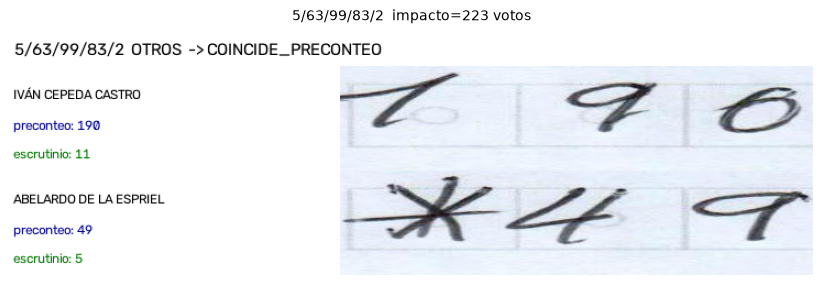

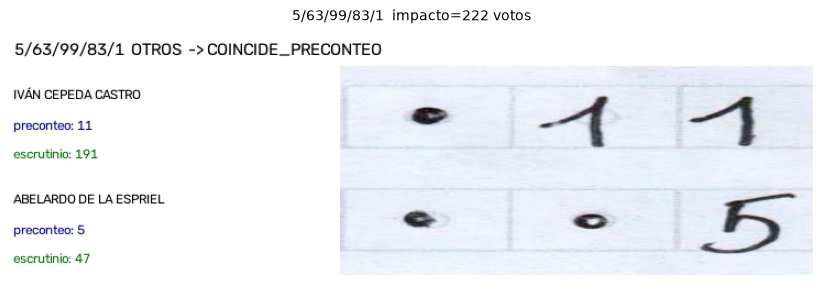

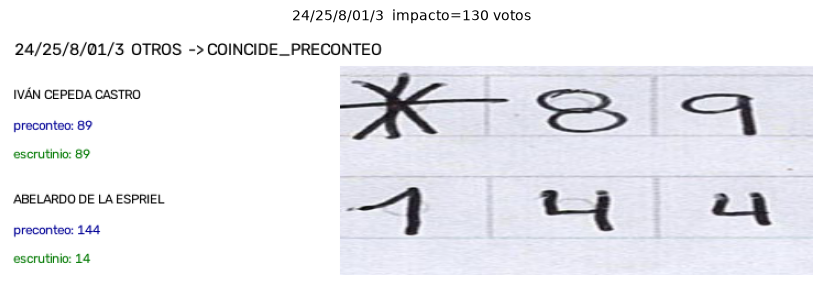

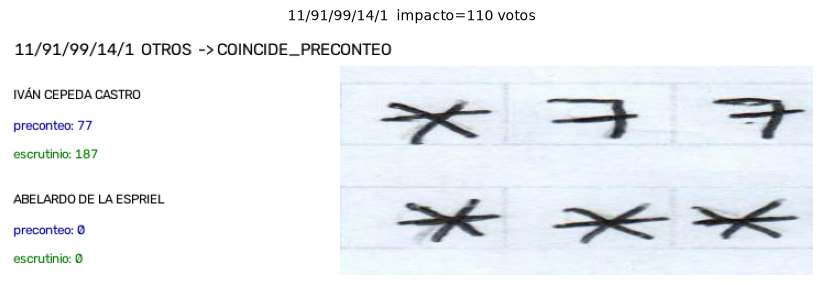

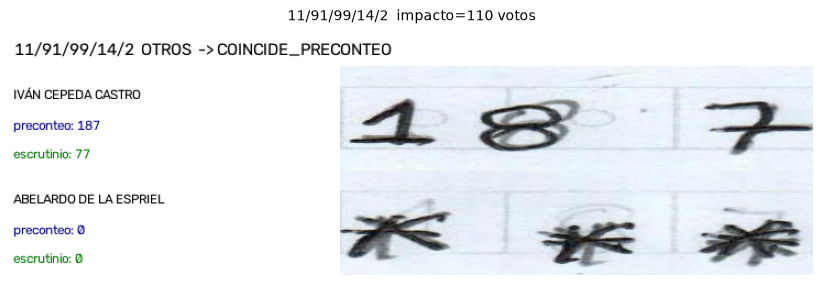

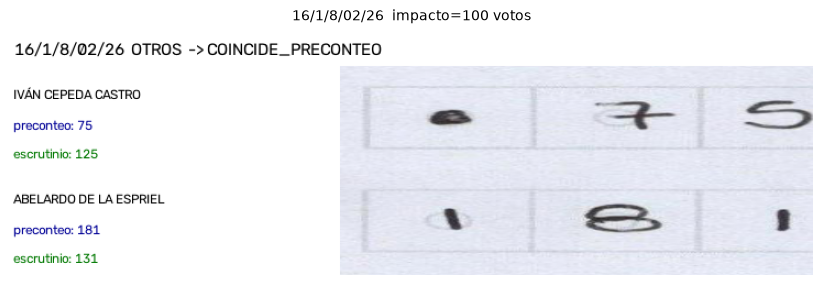

In [6]:
import matplotlib.pyplot as plt
import cv2

CUANTAS = 6
dir_ev = Path(f"{SALIDA}_evidencia")

for _, r in rev.head(CUANTAS).iterrows():
    png = dir_ev / f"{int(r['dep']):02d}_{int(r['muni']):03d}_{int(r['zona']):02d}_{r['puesto']}_{int(r['mesa']):03d}.png"
    if not png.exists():
        print("sin evidencia:", png.name); continue
    img = cv2.imread(str(png))
    plt.figure(figsize=(11, 3.2))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
    plt.title(f"{r['dep']}/{r['muni']}/{r['zona']}/{r['puesto']}/{r['mesa']}  "
              f"impacto={r['impacto_votos']:.0f} votos", fontsize=10)
    plt.show()

## 4 · Qué hacer con el resultado

Avisame con estos tres números y actualizo el informe consolidado:

1. **Cuántas** mesas respaldan al preconteo (el escrutinio se apartó del acta).
2. **Si hay direccionalidad** (el `p` de la celda 2.2).
3. **Si la evidencia visual confirma** los casos de más impacto.

El informe [`docs/INFORME_2V.md`](../docs/INFORME_2V.md) lee estos veredictos del
CSV, así que basta con regenerarlo apuntando `--dirimidas` a la salida de aquí:

```bash
python -m e14.informe.consolidado \
    --mmv data/manifests/MMV_2V/MMV_Presidente2V_2026 \
    --control data/manifests/MMV_1V/MMV_Presidente1V_2026 \
    --dirimidas data/segunda_vuelta/_oficial/dirimidas_otros_2v.csv \
    --ronda "Presidencia 2026 · 2ª vuelta" --out docs/INFORME_2V.md
```

⚠️ Y lo de siempre: esto **no dictamina fraude**. Es una lista de candidatas a
revisión con su evidencia. El juicio es humano.